In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

from sklearn.metrics import(mean_absolute_error,
    mean_squared_error,
    r2_score)
import shap
import joblib

In [3]:
## import featured dat
data = pd.read_csv("../data_folder/feature_engineerd_data.csv")

In [4]:
##viewing top two rows
data.head(2)

,Unnamed: 0,Order_Date,Season,Country,Category,Sub_Category,Product_Name,Unit_Price,Quantity,Discount,...,Profit_Margin_%,Shipping_Cost,Shipping_Days,Payment_Method,Month,Year,revenue_per_unit,profit_per_unit,scost_per_revenue,net_revenue
0,0,2023-01-18,Winter,Mexico,Electronics,Smartphones,Xiaomi 13,520.40,7,0.00,...,32.91,2.25,4,Google Pay,1970-01-01 00:00:00.000000001,1970-01-01 00:00:00.000002023,520.40,171.241429,0.000618,1619.022222
1,1,2023-11-13,Fall,USA,Books & Media,Books,Thinking Fast and Slow,22.59,2,0.25,...,16.41,4.72,5,Credit Card,1970-01-01 00:00:00.000000011,1970-01-01 00:00:00.000002023,16.94,2.780000,0.139315,7.177966


In [5]:
# Our target variable is profit

y = data["Profit"]

In [6]:
#viewing the column features we have
data.columns

Index(['Unnamed: 0', 'Order_Date', 'Season', 'Country', 'Category',
       'Sub_Category', 'Product_Name', 'Unit_Price', 'Quantity', 'Discount',
       'Revenue', 'Cost', 'Profit', 'Profit_Margin_%', 'Shipping_Cost',
       'Shipping_Days', 'Payment_Method', 'Month', 'Year', 'revenue_per_unit',
       'profit_per_unit', 'scost_per_revenue', 'net_revenue'],
      dtype='object')

In [7]:
## dropping columns that directly reveal profit

data = data.drop(columns = ["Month", "Order_Date", "Revenue", "Cost", "net_revenue","Year","scost_per_revenue", "revenue_per_unit", "profit_per_unit", "Profit_Margin_%" ])

In [8]:
## viewing column to confirm removal
data.head(2)

,Unnamed: 0,Season,Country,Category,Sub_Category,Product_Name,Unit_Price,Quantity,Discount,Profit,Shipping_Cost,Shipping_Days,Payment_Method
0,0,Winter,Mexico,Electronics,Smartphones,Xiaomi 13,520.40,7,0.00,1198.69,2.25,4,Google Pay
1,1,Fall,USA,Books & Media,Books,Thinking Fast and Slow,22.59,2,0.25,5.56,4.72,5,Credit Card


In [9]:
# checking the data shape:  1000 rows and 13 columns
data.shape

(10000, 13)

In [10]:
## assigning our x data to be used for x_train and x_test
x = data[ [
        "Season",
        "Country",
        "Category",
        "Sub_Category",
        "Product_Name",
        "Unit_Price",
        "Quantity",
        "Discount",
        "Shipping_Cost",
        "Shipping_Days",
        "Payment_Method"
    ]]

In [11]:
## Identifying numerical and categorical columns

numerical_columns = x.select_dtypes(include=["int64", "float64"]).columns

categorical_columns = x.select_dtypes(include=["object"]).columns

In [12]:
#list of numerical columns
numerical_columns

Index(['Unit_Price', 'Quantity', 'Discount', 'Shipping_Cost', 'Shipping_Days'], dtype='object')

In [13]:
#list of categirical column

categorical_columns

Index(['Season', 'Country', 'Category', 'Sub_Category', 'Product_Name',
       'Payment_Method'],
      dtype='object')

In [14]:
## Encoding categorical data

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown = "ignore"),
            categorical_columns
        )
    ],
    remainder="passthrough"
)

In [15]:
## splitting the data

x_train, x_test, y_train, y_test =train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 34
)

In [16]:
## Training using MODEL 1(Linear regression)


First_pipeline = Pipeline([
    ("preprocessor", preprocessor),
("model", LinearRegression())])

In [17]:
First_pipeline.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
#checking predictions

first_pred = First_pipeline.predict(x_test)

In [19]:
first_pred

array([-74.72113941, 295.40119484, -45.46911584, ..., -37.64060985,
       684.53856491,  89.98667781], shape=(2000,))

In [20]:
## Evaluation

MAE = mean_absolute_error(y_test, first_pred)
MAE

141.2756424523951

In [21]:
MSE = np.sqrt(mean_squared_error(y_test, first_pred))
MSE

np.float64(302.5810078106694)

In [22]:
R2 = r2_score(y_test, first_pred)
R2

0.43707798291734257

In [23]:
## Model 2(Randomforestregressor)



rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=20,
        random_state = 34
    ))
])

In [24]:
#fitting our model randomforestregressor

rf_pipeline.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [25]:
rf_pred = rf_pipeline.predict(x_test)
rf_pred

array([  64.4115,  352.5145,    5.102 , ...,  -16.656 , 1061.9665,
         19.388 ], shape=(2000,))

In [26]:
## evaluate


rf_MAE = mean_absolute_error(y_test, rf_pred)
print(rf_MAE)
rf_R2 = r2_score(y_test, rf_pred)
print(rf_R2)
rf_MSE = np.sqrt(mean_squared_error(y_test, rf_pred))
print(rf_MSE)

54.051301
0.836847705045906
162.89739565325237


In [27]:
## Model 3(Gradient Boosting)


gbpipeline = Pipeline([
    ("Preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        random_state = 34
    ))

])

In [28]:
gbpipeline.fit(x_train, y_train)

,steps,"[('Preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [29]:
gb_pred = gbpipeline.predict(x_test)
gb_pred

array([ -11.81433327,  323.13177692,    7.15991211, ...,  -45.21024006,
       1076.16344906,   -1.34769767], shape=(2000,))

In [30]:
## evaluate


gb_MAE = mean_absolute_error(y_test, gb_pred)
print(gb_MAE)
gb_R2 = r2_score(y_test, gb_pred)
print(gb_R2)
gb_MSE = np.sqrt(mean_squared_error(y_test, gb_pred))
print(gb_MSE)

61.68679573631301
0.8453293097971871
158.6067109648302


In [31]:
## Model 4(XGBRegressor)


xgbpipeline = Pipeline([
    ("Preprocessor", preprocessor),
    ("model", XGBRegressor(
        objective='reg:squarederror',
        n_estimators=100, random_state=34
    ))

])

In [32]:
xgbpipeline.fit(x_train, y_train)

,steps,"[('Preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [33]:
xgb_pred = gbpipeline.predict(x_test)
xgb_pred

array([ -11.81433327,  323.13177692,    7.15991211, ...,  -45.21024006,
       1076.16344906,   -1.34769767], shape=(2000,))

In [34]:
## evaluate


xgb_MAE = mean_absolute_error(y_test, xgb_pred)
print(xgb_MAE)
xgb_R2 = r2_score(y_test, xgb_pred)
print(xgb_R2)
xgb_RMSE = np.sqrt(mean_squared_error(y_test, xgb_pred))
print(xgb_RMSE)

61.68679573631301
0.8453293097971871
158.6067109648302


In [35]:
## Model 5(DecisionTreeRegressor)


despipeline = Pipeline([
    ("Preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(
    ))

])

In [36]:
despipeline.fit(x_train, y_train)

,steps,"[('Preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [37]:
des_pred = despipeline.predict(x_test)
des_pred

array([ 66.52, 324.05,   6.77, ..., -43.08, 786.02,  23.48], shape=(2000,))

** Linear Regression did better**

In [38]:
## evaluate


des_MAE = mean_absolute_error(y_test, des_pred)
print(des_MAE)
des_R2 = r2_score(y_test, des_pred)
print(des_R2)
des_MSE = np.sqrt(mean_squared_error(y_test, des_pred))
print(des_MSE)

74.73998499999999
0.6515892045668088
238.04734881163873


In [39]:
# MAE,MSE,R2, rf_MAE,rf_MSE,rf_R2, gb_MAE,gb_MSE,gb_R2,

compare_model = pd.DataFrame([[MAE,MSE,R2], [rf_MAE,rf_MSE,rf_R2],[ gb_MAE,gb_MSE,gb_R2],[xgb_MAE, xgb_RMSE, xgb_R2],[des_MAE, des_MSE, des_R2]],
                            index=["Linear Regression", "RandomForest Regressor", "Gradient Boosting", "XGBRegressor", "DecisionTreeRegressor" ],
                            columns= ["MAE", "MSE", "R2"])
compare_model

,MAE,MSE,R2
Linear Regression,141.275642,302.581008,0.437078
RandomForest Regressor,54.051301,162.897396,0.836848
Gradient Boosting,61.686796,158.606711,0.845329
XGBRegressor,61.686796,158.606711,0.845329
DecisionTreeRegressor,74.739985,238.047349,0.651589


In [40]:
x.columns

Index(['Season', 'Country', 'Category', 'Sub_Category', 'Product_Name',
       'Unit_Price', 'Quantity', 'Discount', 'Shipping_Cost', 'Shipping_Days',
       'Payment_Method'],
      dtype='object')

In [41]:
## performing hyperparameter tuning for xgboost

param_grid = {
    "model__n_estimators": [100, 200, 300],
    'model__max_depth': [3, 6, 9],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}


grid_search = GridSearchCV(
    estimator=xgbpipeline, param_grid=param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(x_train, y_train)

print("Best parameters:", grid_search.best_params_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 100, 'model__subsample': 1.0}


In [42]:
best_xgb = grid_search.best_estimator_

best_xgb_pred = best_xgb.predict(x_test)

best_xgb_mae = mean_absolute_error(y_test, best_xgb_pred)
best_xgb_rmse = np.sqrt(mean_squared_error(y_test, best_xgb_pred))
best_xgb_r2 = r2_score(y_test, best_xgb_pred)

print("MAE :", best_xgb_mae)
print("RMSE:", best_xgb_rmse)
print("R²  :", best_xgb_r2)

MAE : 54.190859741994444
RMSE: 155.80455486181606
R²  : 0.8507462660657306


In [43]:
xgb_param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [3, 5, 6, 8, 10],
    "model__min_child_weight": [1, 3, 5],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__gamma": [0, 0.1, 0.3, 0.5],
    "model__reg_alpha": [0, 0.1, 1],
    "model__reg_lambda": [1, 2, 5]
}

In [44]:
xgb_random = RandomizedSearchCV(
    estimator=xgbpipeline,
    param_distributions=xgb_param_grid,
    n_iter=50,          # Try 50 random combinations
    scoring="r2",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(x_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': [0.6, 0.8, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], ...}"
,n_iter,50
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [45]:
print("Best Parameters:")
print(xgb_random.best_params_)

print("\nBest Cross-Validation R²:")
print(xgb_random.best_score_)

Best Parameters:
{'model__subsample': 1.0, 'model__reg_lambda': 2, 'model__reg_alpha': 0, 'model__n_estimators': 300, 'model__min_child_weight': 1, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__gamma': 0.3, 'model__colsample_bytree': 1.0}

Best Cross-Validation R²:
0.8809942371665841


In [46]:
best_xgb = xgb_random.best_estimator_

In [47]:
best_xgb

,steps,"[('Preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [48]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print(f"MAE  : {xgb_mae:.4f}")
print(f"RMSE : {xgb_rmse:.4f}")
print(f"R²   : {xgb_r2:.4f}")

MAE  : 61.6868
RMSE : 158.6067
R²   : 0.8453


In [49]:
## tuning gradient boosting


gb_param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4, 5],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__subsample": [0.8, 1.0],
    "model__max_features": ["sqrt", "log2", None]
}


In [50]:
gb_random = RandomizedSearchCV(
    estimator=gbpipeline,
    param_distributions=gb_param_grid,
    n_iter=50,
    scoring="r2",
    cv=5,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

gb_random.fit(x_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,estimator,Pipeline(step...m_state=34))])
,param_distributions,"{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], ...}"
,n_iter,50
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [51]:
print("Best Parameters:")
print(gb_random.best_params_)

print("\nBest Cross-Validation R²:")
print(gb_random.best_score_)

Best Parameters:
{'model__subsample': 0.8, 'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': 5, 'model__learning_rate': 0.05}

Best Cross-Validation R²:
0.8754521665324443


In [52]:
## Tuning random forest regressor hyperparameters to impeove on its default settings

from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'model__n_estimators': [50],
    'model__max_depth': [20],
    'model__min_samples_split': [5],
    'model__min_samples_leaf': [1, 2]
}

random_search = RandomizedSearchCV(
    estimator = rf_pipeline,
    param_distributions = param_grid,
    n_iter = 30,
    cv=5,
    scoring='r2',
    random_state = 34,
    n_jobs=-1
)

random_search.fit(x_train, y_train)

random_search.best_params_
random_search.best_score_


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 2 is smaller than n_iter=30. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


np.float64(0.8552718025618239)

In [53]:
results = pd.DataFrame({
    "Model": [
        "Random Forest (Tuned)",
        "Gradient Boosting (Tuned)",
        "XGBoost (Tuned)"
    ],
    "MAE": [rf_MAE, gb_MAE, best_xgb_mae],
    "RMSE": [rf_MSE, gb_MSE, best_xgb_rmse],
    "R²": [rf_R2, gb_R2, best_xgb_r2]
})

results.sort_values("R²", ascending=False)

,Model,MAE,RMSE,R²
2,XGBoost (Tuned),54.190860,155.804555,0.850746
1,Gradient Boosting (Tuned),61.686796,158.606711,0.845329
0,Random Forest (Tuned),54.051301,162.897396,0.836848


In [54]:
best_xgb = xgb_random.best_estimator_

xgb_pred = best_xgb.predict(x_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²  :", xgb_r2)

MAE : 54.57733805378676
RMSE: 153.9562076073135
R²  : 0.854266527164746


** XGBOOST is the best performing model

# Answering Business questions with the trained model

In [55]:
# best model
best_model = best_xgb

In [56]:
#features names

feature_names = best_model.named_steps["Preprocessor"].get_feature_names_out()

print(feature_names)

['cat__Season_Fall' 'cat__Season_Spring' 'cat__Season_Summer'
 'cat__Season_Winter' 'cat__Country_Canada' 'cat__Country_China'
 'cat__Country_Egypt' 'cat__Country_France' 'cat__Country_Germany'
 'cat__Country_India' 'cat__Country_Italy' 'cat__Country_Japan'
 'cat__Country_Jordan' 'cat__Country_Kuwait' 'cat__Country_Mexico'
 'cat__Country_Saudi Arabia' 'cat__Country_Singapore'
 'cat__Country_South Korea' 'cat__Country_Spain' 'cat__Country_UAE'
 'cat__Country_UK' 'cat__Country_USA' 'cat__Category_Beauty & Health'
 'cat__Category_Books & Media' 'cat__Category_Clothing'
 'cat__Category_Electronics' 'cat__Category_Home & Kitchen'
 'cat__Sub_Category_Appliances' 'cat__Sub_Category_Books'
 'cat__Sub_Category_Footwear' 'cat__Sub_Category_Furniture'
 'cat__Sub_Category_Headphones' 'cat__Sub_Category_Kitchen Tools'
 'cat__Sub_Category_Laptops' "cat__Sub_Category_Men's Wear"
 'cat__Sub_Category_Skincare' 'cat__Sub_Category_Smartphones'
 'cat__Sub_Category_Software' 'cat__Sub_Category_Supplements'

In [57]:
#extracting importance

importance = best_model.named_steps["model"].feature_importances_

In [58]:
# datadrame for feature importance

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
118,remainder__Unit_Price,0.223006
120,remainder__Discount,0.204185
119,remainder__Quantity,0.177570
33,cat__Sub_Category_Laptops,0.040482
25,cat__Category_Electronics,0.019272
7,cat__Country_France,0.019059
17,cat__Country_South Korea,0.017558
63,cat__Product_Name_Google Pixel 7,0.015323
64,cat__Product_Name_HP Spectre x360,0.014788
61,cat__Product_Name_Dell XPS 15,0.013358


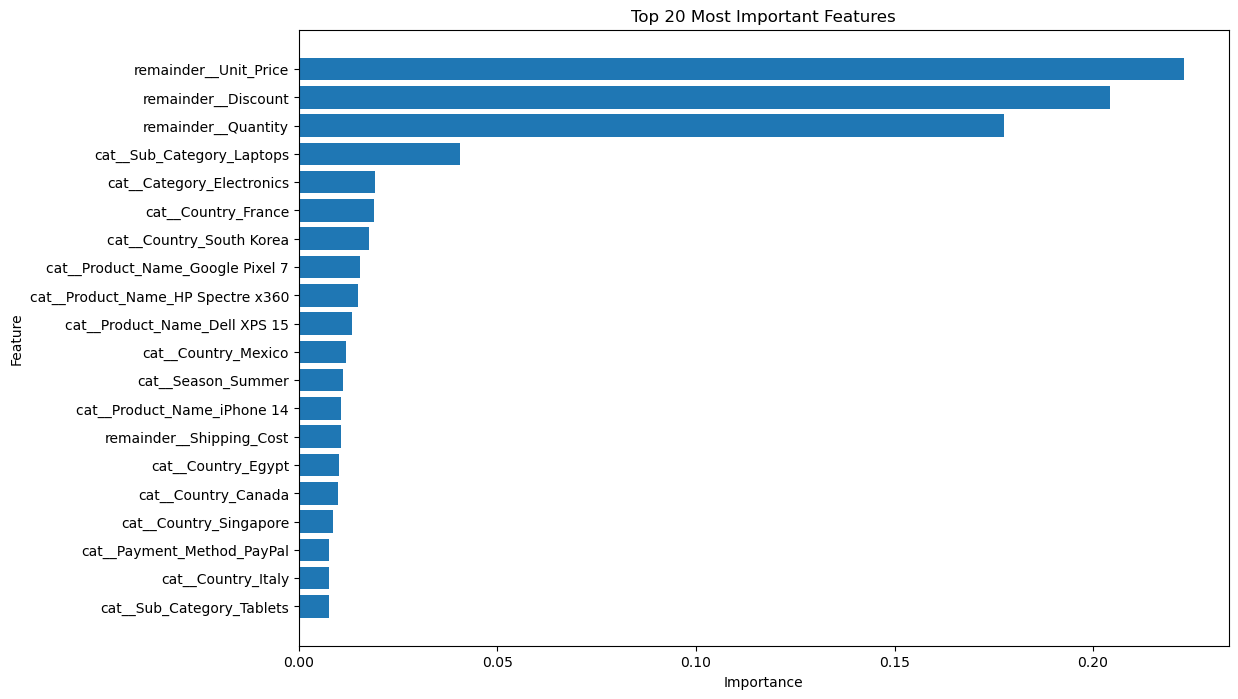

In [59]:
# visualizing feature importance

import matplotlib.pyplot as plt

top20 = importance_df.head(20)

plt.figure(figsize=(12,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Most Important Features")

plt.gca().invert_yaxis()

plt.show()

# NOTES
1)The feature importance analysis revealed that Unit Price, Discount, and Quantity are the three most influential variables in predicting product profitability. This suggests that pricing strategy and sales volume have the greatest impact on profit generation.

2)Among the categorical variables, the Laptop sub-category and the broader Electronics category ranked highly, indicating that certain product segments contribute more strongly to profitability than others.

3)Country-specific features such as France, South Korea, and Mexico also appeared among the top predictors, suggesting that geographic markets influence profitability, although their impact is lower than pricing-related factors.

4)Shipping Cost and Payment Method had relatively small importance scores, implying that while they contribute to predictions, they are less influential than product pricing and demand.

In [60]:
## Model interpretation

In [61]:
xgb_model = best_xgb.named_steps["model"]

In [62]:
#transforming test data

X_test_processed = best_xgb.named_steps["Preprocessor"].transform(x_test)

In [63]:
## retrieving feature names

feature_names = best_xgb.named_steps[
    "Preprocessor"
].get_feature_names_out()

In [64]:
#explaining with shap

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test_processed)

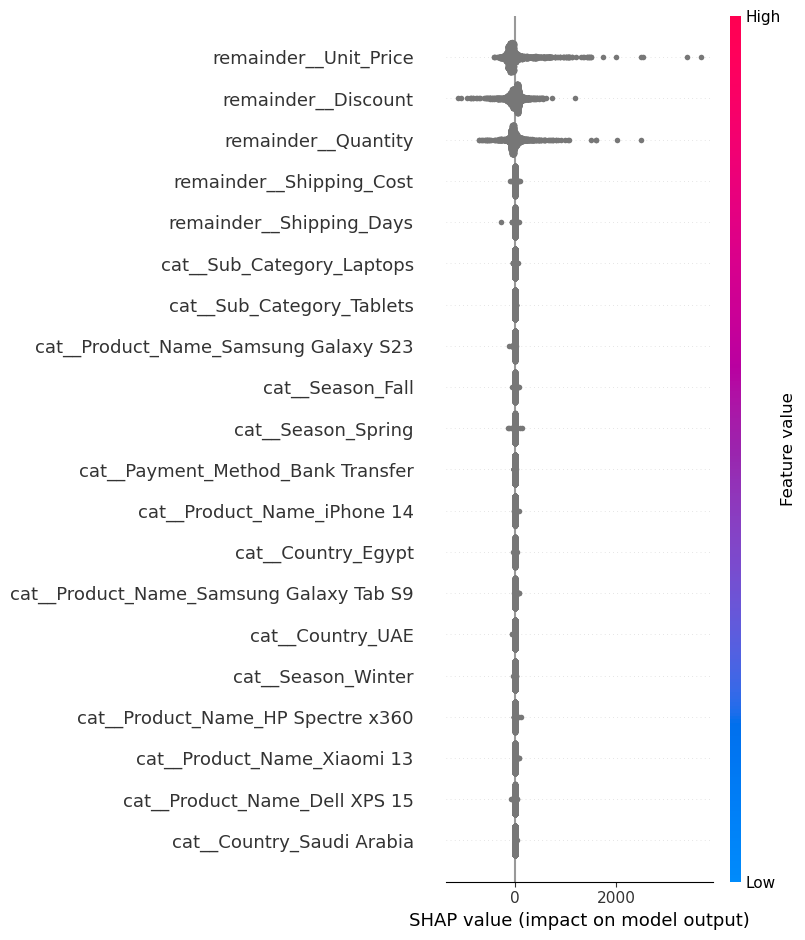

In [65]:
## shap summary plot

shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

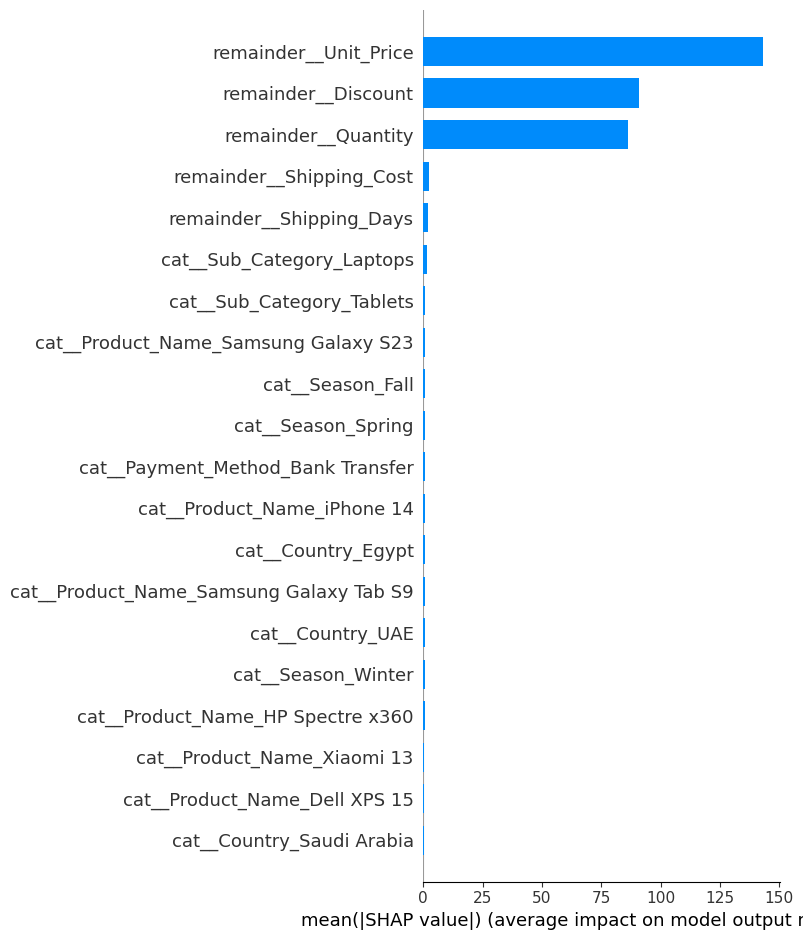

In [66]:
## sha features inportance

shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    plot_type="bar"
)

In [67]:
X_test_dense = X_test_processed.toarray()

In [68]:
type(X_test_processed)

scipy.sparse._csr.csr_matrix

In [69]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test_dense)

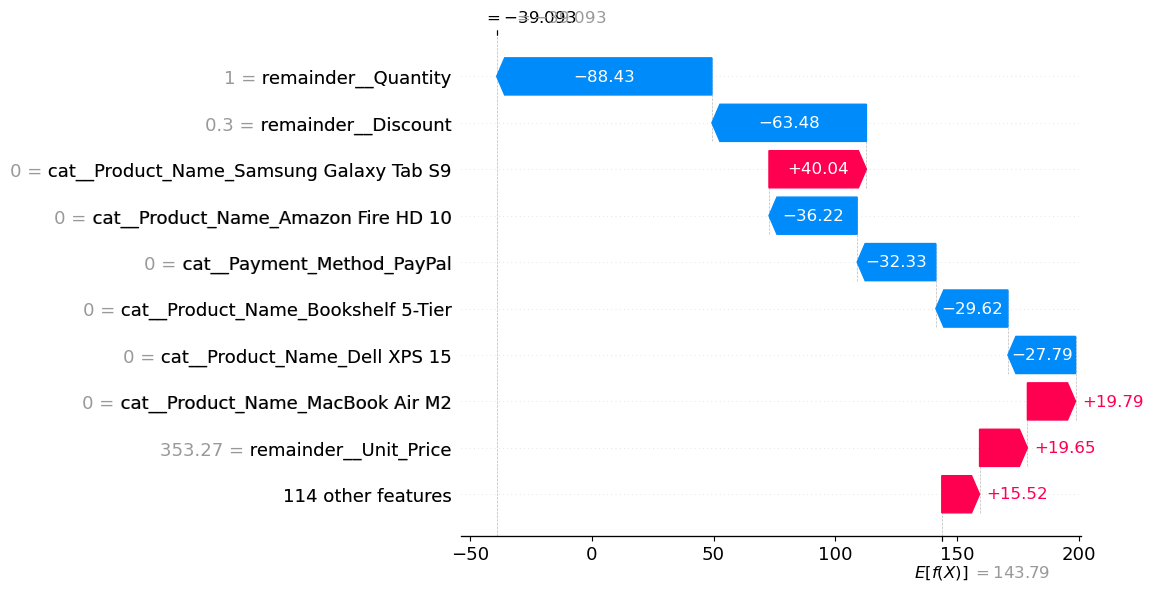

In [70]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test_dense[0],
        feature_names=feature_names
    )
)

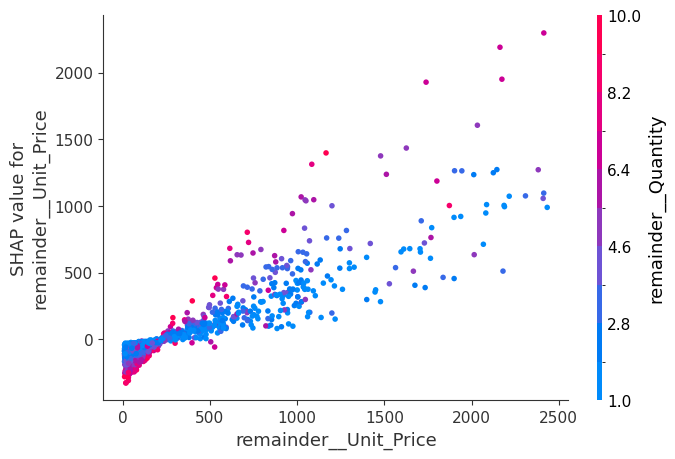

In [71]:
shap.dependence_plot(
    "remainder__Unit_Price",
    shap_values,
    X_test_dense,
    feature_names=feature_names
)

In [72]:
3# saving the model
joblib.dump(best_xgb, "../models/profit_predicted.pk1")

['../models/profit_predicted.pk1']

In [73]:
loaded_model = joblib.load("profit_prediction_model.pkl")

In [74]:
loaded_model

,steps,"[('Preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [75]:
new_transaction = pd.DataFrame({
    "Season": ["Summer"],
    "Country": ["Japan"],
    "Category": ["Electronics"],
    "Sub_Category": ["Laptop"],
    "Product_Name": ["Dell XPS 13"],
    "Unit_Price": [1200],
    "Quantity": [4],
    "Discount": [10],
    "Shipping_Cost": [35],
    "Shipping_Days": [5],
    "Payment_Method": ["Credit Card"]
})

In [76]:
predicted_profit = loaded_model.predict(new_transaction)

In [77]:
f"Predicted Profit: ${predicted_profit[0]:,.2f}"

'Predicted Profit: $-98.40'